# Sid — Regression Models

Predicting the actual Democratic vote share (dem_vote_share) 
at county level using demographic and socioeconomic features.

**Input:** `../data/processed/model_ready_dataset.csv`
**Models:** Linear Regression, Ridge, Lasso, Random Forest Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

### (2) Load dataset

In [2]:
df = pd.read_csv(
    "../data/processed/model_ready_dataset.csv",
    dtype={"county_fips": str},
    low_memory=False
)

print(f"Shape: {df.shape}")
print(f"Dem vote share stats:")
print(df["dem_vote_share"].describe().round(3))

Shape: (3115, 184)
Dem vote share stats:
count    3115.000
mean        0.333
std         0.160
min         0.031
25%         0.209
50%         0.300
75%         0.424
max         0.921
Name: dem_vote_share, dtype: float64


### (3) Feature selection and split

In [3]:
features = [
    "higher_ed_rate",
    "poverty_rate",
    "unemployment_rate",
    "white_pct",
    "black_pct",
    "asian_pct",
    "median_income",
    "log_population",
    "housing_density"
]

target = "dem_vote_share"

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Target range: {y.min():.3f} to {y.max():.3f}")

Training set: (2491, 9)
Test set:     (623, 9)
Target range: 0.031 to 0.921


### (4) Feature scaling

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling done.")

Scaling done.


### (5) Helper function — evaluate model

In [5]:
def evaluate(name, y_test, y_pred):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    print(f"{name}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    print()
    return {"Model": name, "RMSE": round(rmse,4),
            "MAE": round(mae,4), "R2": round(r2,4)}

### (6) Train all models

In [6]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

# Lasso
lasso = Lasso(alpha=0.001)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("All models trained.")

All models trained.


### (7) Evaluate all models

In [7]:
results = []
results.append(evaluate("Linear Regression", y_test, y_pred_lr))
results.append(evaluate("Ridge",             y_test, y_pred_ridge))
results.append(evaluate("Lasso",             y_test, y_pred_lasso))
results.append(evaluate("Random Forest",     y_test, y_pred_rf))

results_df = pd.DataFrame(results).set_index("Model")
print("=" * 45)
print("MODEL COMPARISON")
print("=" * 45)
display(results_df)

Linear Regression
  RMSE: 0.0934
  MAE:  0.0727
  R²:   0.6468

Ridge
  RMSE: 0.0934
  MAE:  0.0727
  R²:   0.6468

Lasso
  RMSE: 0.0932
  MAE:  0.0725
  R²:   0.6481

Random Forest
  RMSE: 0.0798
  MAE:  0.0594
  R²:   0.7422

MODEL COMPARISON


,RMSE,MAE,R2
Model,,,
Linear Regression,0.0934,0.0727,0.6468
Ridge,0.0934,0.0727,0.6468
Lasso,0.0932,0.0725,0.6481
Random Forest,0.0798,0.0594,0.7422


### (8) Predicted vs Actual — Random Forest

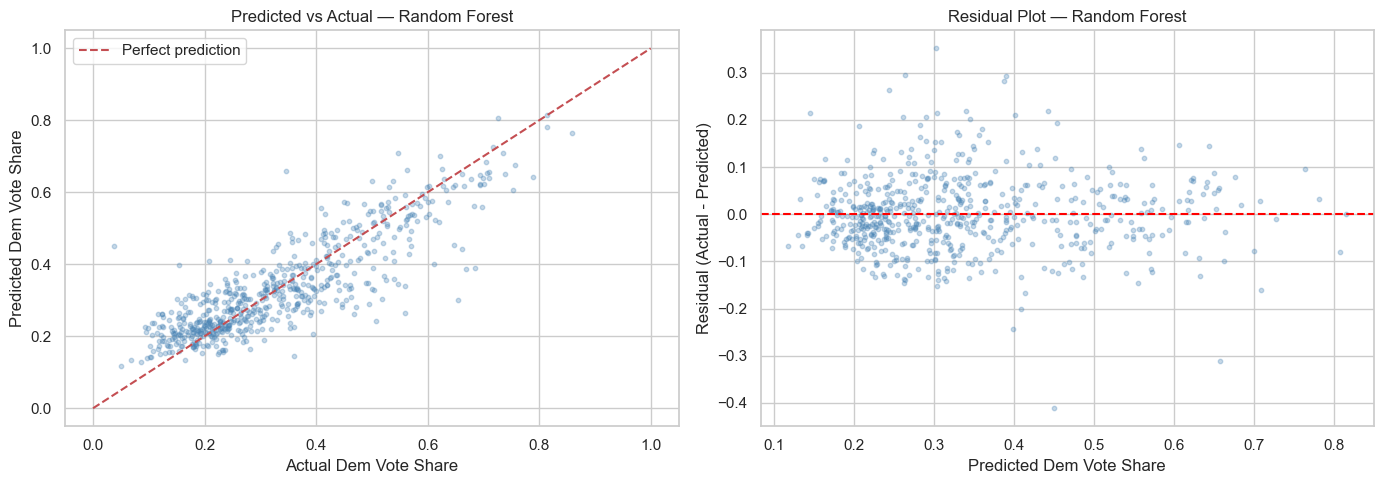

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, s=10, color="steelblue")
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlabel("Actual Dem Vote Share")
axes[0].set_ylabel("Predicted Dem Vote Share")
axes[0].set_title("Predicted vs Actual — Random Forest")
axes[0].legend()

# Residuals
residuals = y_test - y_pred_rf
axes[1].scatter(y_pred_rf, residuals, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Predicted Dem Vote Share")
axes[1].set_ylabel("Residual (Actual - Predicted)")
axes[1].set_title("Residual Plot — Random Forest")

plt.tight_layout()
plt.show()

### (9) Feature importance — Random Forest

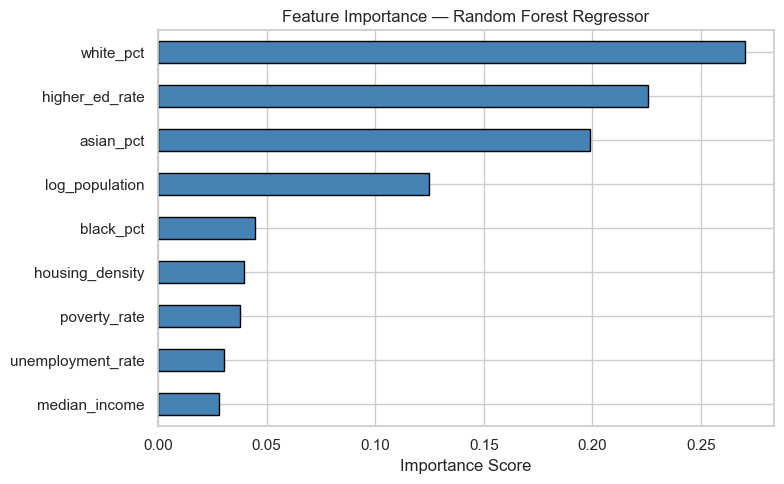


Feature importance ranking:
white_pct            0.2701
higher_ed_rate       0.2255
asian_pct            0.1990
log_population       0.1247
black_pct            0.0448
housing_density      0.0398
poverty_rate         0.0376
unemployment_rate    0.0303
median_income        0.0283
dtype: float64


In [10]:
feat_importance = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind="barh", color="steelblue", edgecolor="black")
plt.title("Feature Importance — Random Forest Regressor")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
print(feat_importance.sort_values(ascending=False).round(4))

### (10) Summary

In [11]:
print("=" * 50)
print("REGRESSION SUMMARY")
print("=" * 50)
print(f"Best model:   Random Forest Regressor")
print(f"R² Score:     0.7422 (explains 74% of variance)")
print(f"RMSE:         0.0798 (~8% avg prediction error)")
print(f"MAE:          0.0594 (~6% median prediction error)")
print()
print("Top predictors of dem_vote_share:")
print("  1. white_pct        (0.270)")
print("  2. higher_ed_rate   (0.226)")
print("  3. asian_pct        (0.199)")
print("  4. log_population   (0.125)")
print()
print("Insight: Linear models plateau at R²=0.65,")
print("Random Forest gains +0.10 by capturing")
print("non-linear demographic interactions.")
print("=" * 50)

REGRESSION SUMMARY
Best model:   Random Forest Regressor
R² Score:     0.7422 (explains 74% of variance)
RMSE:         0.0798 (~8% avg prediction error)
MAE:          0.0594 (~6% median prediction error)

Top predictors of dem_vote_share:
  1. white_pct        (0.270)
  2. higher_ed_rate   (0.226)
  3. asian_pct        (0.199)
  4. log_population   (0.125)

Insight: Linear models plateau at R²=0.65,
Random Forest gains +0.10 by capturing
non-linear demographic interactions.
